In [1]:
# Step 1: Import required libraries

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import accuracy_score

In [2]:
# Step 2: Load Fashion MNIST Dataset

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Step 3: Display dataset shape

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


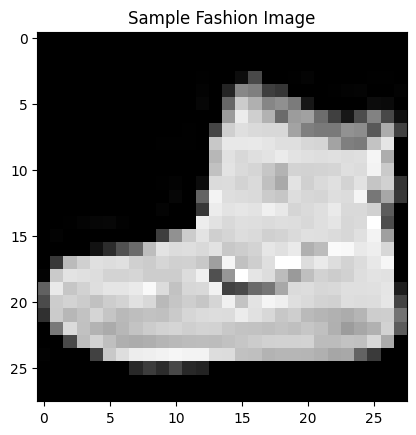

Label: 9


In [5]:
# Step 4: Display one image

plt.imshow(X_train[0], cmap='gray')
plt.title("Sample Fashion Image")
plt.show()
# Step 5: Display corresponding label

print("Label:", y_train[0])

In [6]:
# Step 6: Define class names

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print("Class Name:", class_names[y_train[0]])

Class Name: Ankle boot


In [7]:
# Step 7: Normalize the dataset

X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
# Step 8: Build Deep Neural Network model

model = Sequential()

# Flatten layer converts 28x28 image into 1D vector
model.add(Flatten(input_shape=(28, 28)))

# Hidden Layer 1
model.add(Dense(128, activation='relu'))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Output Layer (10 classes)
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# Step 9: Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Step 10: Display model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Step 11: Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8056 - loss: 0.5684 - val_accuracy: 0.8527 - val_loss: 0.4179
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8598 - loss: 0.3944 - val_accuracy: 0.8570 - val_loss: 0.4075
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8726 - loss: 0.3559 - val_accuracy: 0.8708 - val_loss: 0.3585
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8791 - loss: 0.3310 - val_accuracy: 0.8652 - val_loss: 0.3667
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8867 - loss: 0.3108 - val_accuracy: 0.8771 - val_loss: 0.3438
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8900 - loss: 0.2961 - val_accuracy: 0.8795 - val_loss: 0.3372
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8960 - loss: 0.2831 - val_accuracy: 0.8756 - val_loss: 0.3456
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8998 - loss: 0.2688 - val_accuracy: 0.

In [12]:
# Step 12: Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8707 - loss: 0.3688
Test Loss: 0.36883577704429626
Test Accuracy: 0.8707000017166138


In [13]:
# Step 13: Predict classes

predictions = model.predict(X_test)

print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1.8123346e-05 1.3493620e-07 2.4837582e-05 3.3207143e-05 9.4244788e-06
 5.7739887e-04 1.9296720e-04 4.0192459e-02 1.7056878e-04 9.5878088e-01]


In [14]:
# Step 14: Get predicted class

predicted_class = np.argmax(predictions[0])

print("Predicted Class:", predicted_class)
print("Predicted Label:", class_names[predicted_class])

Predicted Class: 9
Predicted Label: Ankle boot


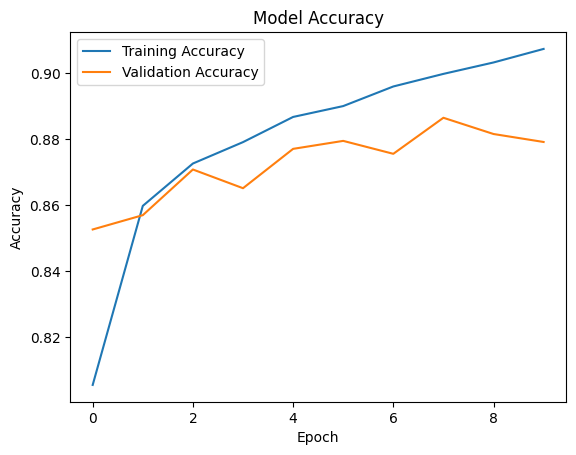

In [15]:
# Step 17: Plot training and validation accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()